##  Quality control for 2D ice sheet model output data: UTAS Elmer/Ice

In [4]:
import numpy as np
import xarray as xr
from matplotlib import pylab as plt
import pandas as pd

In [5]:
basepath = '/home/mkjs0/mount/gadi/'
model = 'UTAS_ElmerIce'
model_base = 'AIS_' + model # this is the text (stays the same) in the actual data file that incorporates the model and usually AIS
model_reso = '4'
pth_scalar_values = '/home/mkjs0/research/python/hackathon/ComputedScalars'

# 1. Check CTRL run

In [6]:
# File paths for CTRL run
exp1='ctrlAE_'+model_reso
exp2='ctrlAE'

mask_floating = 'sftflf_' + model_base + '_' + exp2 + '.nc'
draft = 'base_' + model_base + '_' + exp2 + '.nc'
bmboutput = 'libmassbffl_' + model_base + '_' + exp2 + '.nc'
smb = 'acabf_' + model_base + '_' + exp2 + '.nc'
bed = 'topg_' + model_base + '_' + exp2 + '.nc'
thk = 'lithk_' + model_base + '_' + exp2 + '.nc'

In [7]:
d =xr.open_dataset(basepath+model +'/'+exp1+'/'+mask_floating)

### 1a. Check start and end times

In [8]:
# check start and end dates of simulations
print('start date: ' + d.time.values[0].strftime().split(' ')[0])
print('end date: ' + d.time.values[-1].strftime().split(' ')[0])

start date: 2016-01-01
end date: 2301-01-01


### 1b. Is grid equi distant?


In [9]:
dx_array =d.x.values[1:]-d.x.values[:-1]
dx= np.unique(dx_array)
if len(dx)==1:
    
    print('yes x resolution of ',dx )
else:
    print('WOOOOOPS!')
dy_array =d.y.values[1:]-d.y.values[:-1]
dy = np.unique(dy_array)
if len(dy)==1:
 
    print('yes y resolution of ',dy )
else:
    print('WOOOOOPS!')
dx=dx[0]
dy=dy[0]

yes x resolution of  [4000.]
yes y resolution of  [4000.]


### 1c. Check floating mask

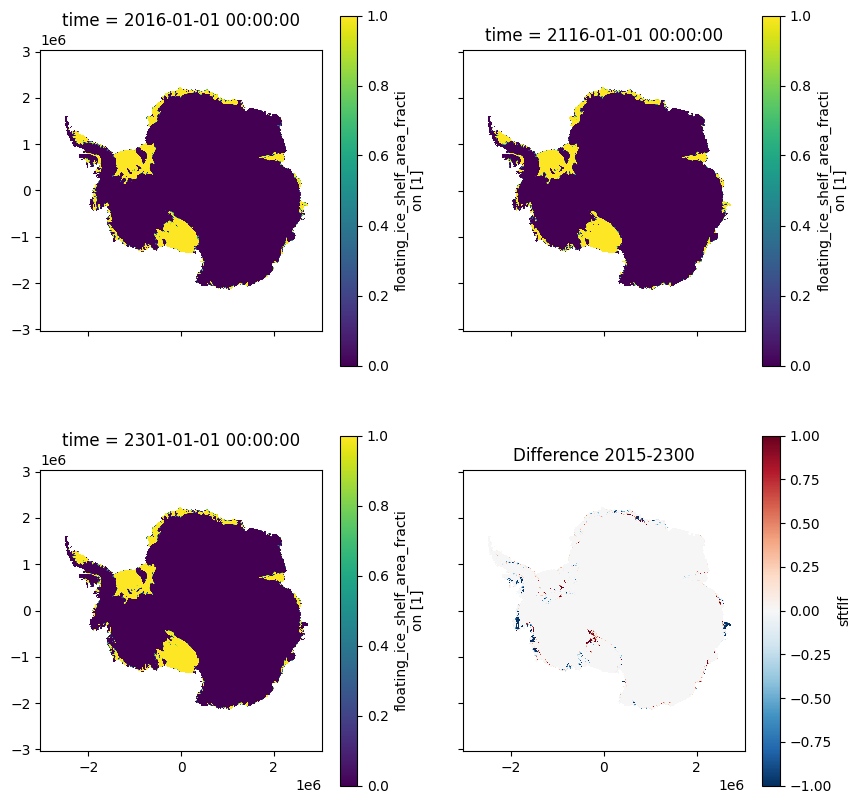

In [10]:
mask = d

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10, 10), sharex = True, sharey = True)
mask.sftflf[0, :, :].plot(ax = ax1)
mask.sftflf[100, :, :].plot(ax = ax2)
mask.sftflf[-1, :, :].plot(ax = ax3)
diff = mask.sftflf[-1,:,:] - mask.sftflf[0,:,:]
diff.plot(ax = ax4)
ax4.set_title('Difference 2015-2300')

[ax.set_ylabel('') for ax in [ax1, ax2, ax3, ax4]]
[ax.set_xlabel('') for ax in [ax1, ax2, ax3, ax4]]

ax1.set_aspect('equal') 
ax2.set_aspect('equal') 
ax3.set_aspect('equal') 
ax4.set_aspect('equal') 

Text(0.5, 0, 'Runtime - years')

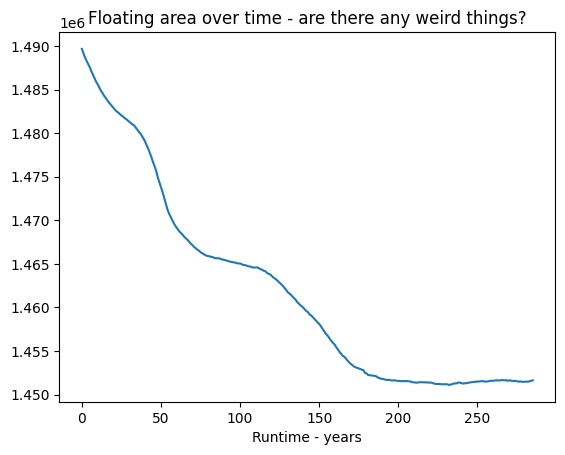

In [11]:
ts = np.nansum(mask.sftflf, axis=(1,2) )*16

plt.figure()
plt.title('Floating area over time - are there any weird things?')
plt.plot(ts)
plt.xlabel('Runtime - years')

### 1d. Check ice shelf thickness

In [12]:
d_draft =xr.open_dataset(basepath+model +'/'+exp1 +'/'+draft)
d_thk = xr.open_dataset(basepath+model +'/'+exp1 +'/'+thk)
d_thk.keys

<bound method Mapping.keys of <xarray.Dataset> Size: 3GB
Dimensions:   (y: 1521, x: 1521, nv: 4, time: 286)
Coordinates:
    lat       (y, x) float64 19MB ...
    lon       (y, x) float64 19MB ...
  * time      (time) object 2kB 2016-01-01 00:00:00 ... 2301-01-01 00:00:00
  * x         (x) float64 12kB -3.04e+06 -3.036e+06 ... 3.036e+06 3.04e+06
  * y         (y) float64 12kB -3.04e+06 -3.036e+06 ... 3.036e+06 3.04e+06
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (y, x, nv) float64 74MB ...
    lithk     (time, y, x) float32 3GB ...
    lon_bnds  (y, x, nv) float64 74MB ...
    mapping   int64 8B ...
Attributes:
    CDI:                  Climate Data Interface version 1.9.10 (https://mpim...
    model_version:        Elmer/Ice v9.0 (Rev: fededfbf7)
    altitude_convention:  altitude reference against geoid EIGEN-6C4
    projection:           espg:3031
    CDO:                  Climate Data Operators version 1.9.10 (https://mpim...
    NCO:                  netCDF Op

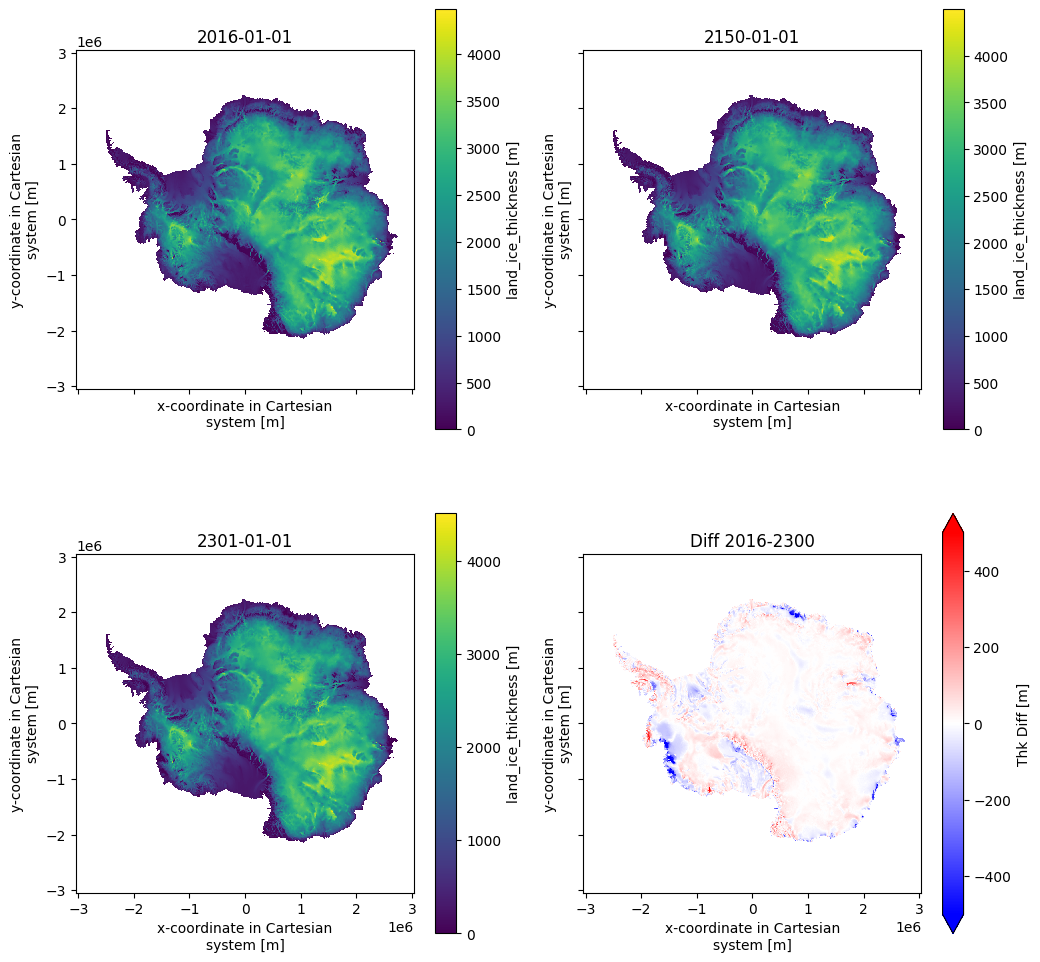

In [13]:
inds =[0, 134, -1]

f, ax = plt.subplots(2, 2, figsize = (12, 12), sharex=True, sharey=True)
ax = ax.flatten()
for i,ind in enumerate(inds):

    d_thk.lithk[ind, :, :].plot(ax = ax[i])
    ax[i].set_title(d.time.values[ind].strftime().split(' ')[0])
    ax[i].set_aspect('equal')

diff = d_thk.lithk[-1, :, :] - d_thk.lithk[0, :, :]
p = diff.plot(ax=ax[3], vmin=-500, vmax=500, cmap='bwr', cbar_kwargs={'label': "Thk Diff [m]"})
ax[3].set_title('Diff 2016-2300')
ax[3].set_aspect('equal')

### 1e.  Is ice shelf draft negative for floating mask?

In [21]:
# d_draft =xr.open_dataset(basepath+model +'/'+exp1 +'/'+draft)

Prints warning if ice shelf draft is above sea level

Text(0.5, 0, 'Runtime - years')

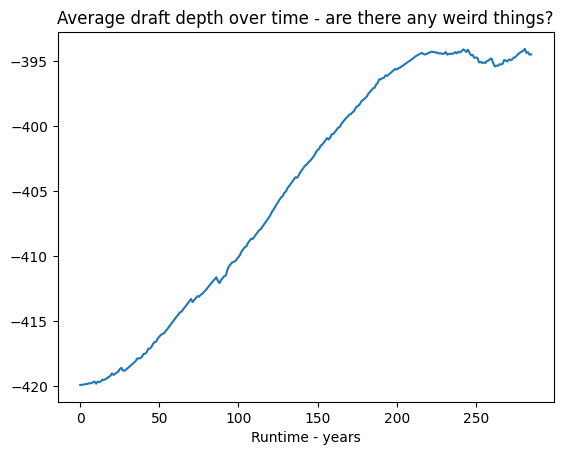

In [23]:
ts = np.zeros([d.time.size,1])

for i in range(d.time.size):
    
    m_in = d.isel(time =i).sftflf #.values
    m = m_in ==1
    shelf_draft =d_draft.base.values[i,]
    mpos = shelf_draft[m]>0
    ts[i] = np.nanmean(shelf_draft[m])
    if mpos.sum()>0:
        print('WOOPS base is above sea level at ' ,years[i])

plt.figure()
plt.plot(ts)
plt.title('Average draft depth over time - are there any weird things?')
plt.xlabel('Runtime - years')
#plt.plot(ts)

###  1f.  What are max and min BMB values? There should be very limited +ve values

In [14]:
d_bmb=xr.open_dataset(basepath+model +'/'+exp1 +'/'+bmboutput)
bmb = d_bmb.libmassbffl.values[0,]*365*24*60*60/917
print('Min BMB (melting):', np.nanmin(bmb), 'm/a')
print('Max BMB (refreezing):', np.nanmax(bmb), 'm/a')

Min BMB (melting): -49.404835 m/a
Max BMB (refreezing): 0.0 m/a


### 1g. Plot example BMB for West Antarctica

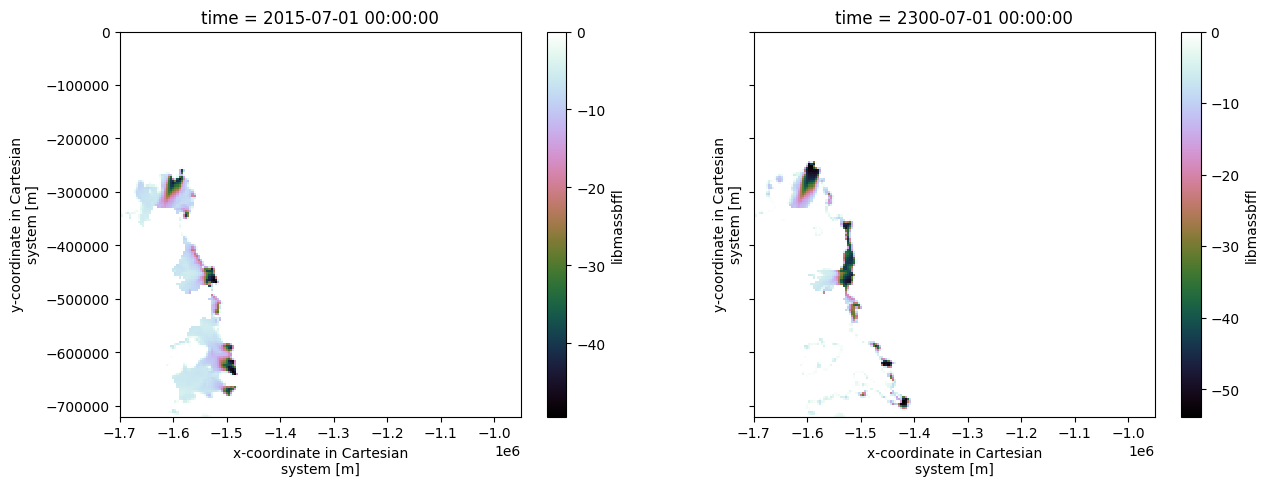

In [15]:
y_range = (-720000, 0)
x_range = (-1700000, -950000)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for i in range(2):
    bmb = d_bmb.libmassbffl[0 if i==0 else -1, :, :] * 365 * 24 * 60 * 60 / 917
    bmb.plot(ax=ax[i], cmap='cubehelix')#, vmin=-100, vmax=0)
    ax[i].set_xlim(x_range)
    ax[i].set_ylim(y_range)
    ax[i].set_aspect('equal')

### 1h. Check for basal melt on grounded cells ?

Prints warning if melt is found on grounded cells

In [16]:
for i in range(d.time.size):
    m_in=d.sftflf.values[i,]
    m = m_in ==0
    bmb_grounded=d_bmb.libmassbffl.values[i,]
    mpos = bmb_grounded[m]>0
    if mpos.sum()>0:
        print('WOOPS melting at fully grounded cells ' ,years[i])


### 1i. Plot total BMB over time

In [18]:
tendlibmassbf = 'tendlibmassbf_' + model_base + '_' + exp2 + '.nc'
tendlibmassbffl = 'tendlibmassbffl_' + model_base + '_' + exp2 + '.nc'

# dbmb1 =xr.open_dataset(basepath + '/' + model + '/' + exp1 + '/' + tendlibmassbf)
dbmb2 =xr.open_dataset(basepath + '/' + model + '/' + exp1 + '/' + tendlibmassbffl)

# line1, = plt.plot(dbmb1.tendlibmassbf, label='Total BMB')
line2, = plt.plot(dbmb2.tendlibmassbffl, label='Floating BMB')
plt.legend()
plt.xlabel('Runtime - years')

diff=dbmb1.tendlibmassbf-dbmb2.tendlibmassbffl


AttributeError: 'Dataset' object has no attribute 'tendlibmassbffl'

# 2. Check experiment ExpAE05

In [19]:
# File paths for expAE05
exp1='expAE05_'+model_reso
exp2='expAE05'

mask_floating = 'sftflf_' + model_base + '_' + exp2 + '.nc'
draft = 'base_' + model_base + '_' + exp2 + '.nc'
bmboutput = 'libmassbffl_' + model_base + '_' + exp2 + '.nc'
smb = 'acabf_' + model_base + '_' + exp2 + '.nc'
bed = 'topg_' + model_base + '_' + exp2 + '.nc'
thk = 'lithk_' + model_base + '_' + exp2 + '.nc'

In [20]:
d =xr.open_dataset(basepath+model +'/'+exp1+'/'+mask_floating)

### 2a. Check start and end times

In [21]:
# check start and end dates of simulations
print('start date: ' + d.time.values[0].strftime().split(' ')[0])
print('end date: ' + d.time.values[-1].strftime().split(' ')[0])

start date: 2016-01-01
end date: 2301-01-01


### 2b. Is grid equi distant?


In [22]:
dx_array =d.x.values[1:]-d.x.values[:-1]
dx= np.unique(dx_array)
if len(dx)==1:
    
    print('yes x resolution of ',dx )
else:
    print('WOOOOOPS!')
dy_array =d.y.values[1:]-d.y.values[:-1]
dy = np.unique(dy_array)
if len(dy)==1:
 
    print('yes y resolution of ',dy )
else:
    print('WOOOOOPS!')
dx=dx[0]
dy=dy[0]

yes x resolution of  [4000.]
yes y resolution of  [4000.]


### 2c. Check floating mask

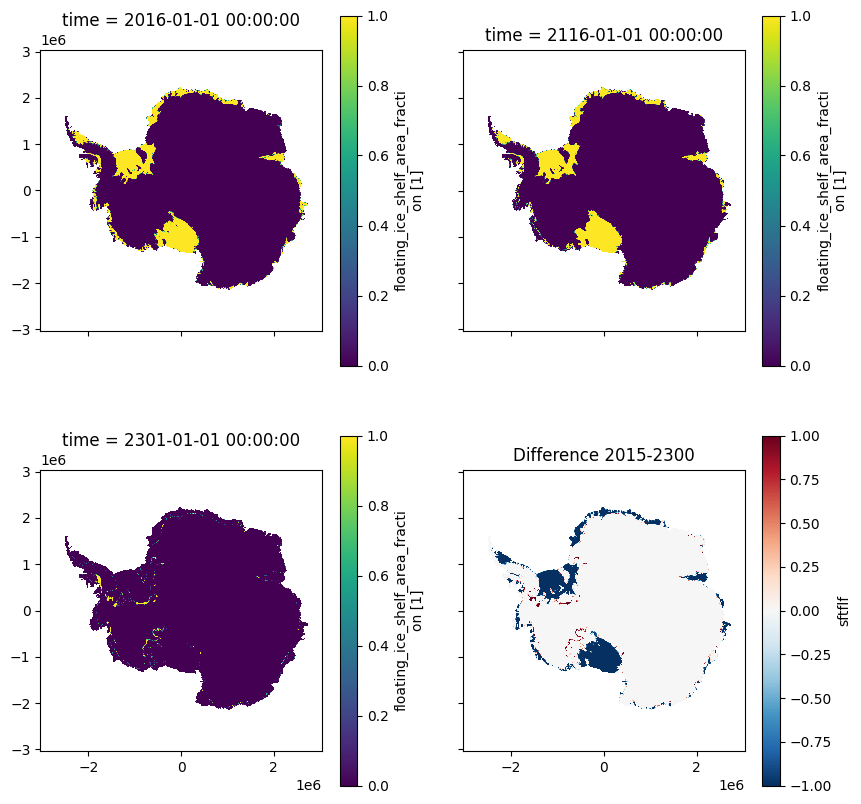

In [23]:
mask = d

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10, 10), sharex = True, sharey = True)
mask.sftflf[0, :, :].plot(ax = ax1)
mask.sftflf[100, :, :].plot(ax = ax2)
mask.sftflf[-1, :, :].plot(ax = ax3)
diff = mask.sftflf[-1,:,:] - mask.sftflf[0,:,:]
diff.plot(ax = ax4)
ax4.set_title('Difference 2015-2300')

[ax.set_ylabel('') for ax in [ax1, ax2, ax3, ax4]]
[ax.set_xlabel('') for ax in [ax1, ax2, ax3, ax4]]

ax1.set_aspect('equal') 
ax2.set_aspect('equal') 
ax3.set_aspect('equal') 
ax4.set_aspect('equal') 

Text(0.5, 0, 'Runtime - years')

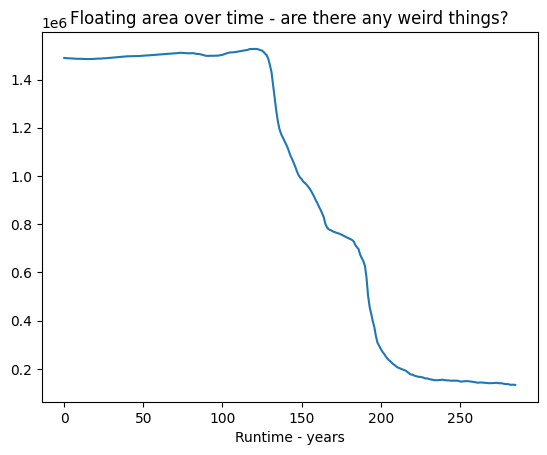

In [24]:
ts = np.nansum(mask.sftflf, axis=(1,2) )*16

plt.figure()
plt.title('Floating area over time - are there any weird things?')
plt.plot(ts)
plt.xlabel('Runtime - years')

### 2d. Check ice shelf thickness

In [25]:
d_draft =xr.open_dataset(basepath+model +'/'+exp1 +'/'+draft)
d_thk = xr.open_dataset(basepath+model +'/'+exp1 +'/'+thk)
d_thk.keys

<bound method Mapping.keys of <xarray.Dataset> Size: 3GB
Dimensions:   (y: 1521, x: 1521, nv: 4, time: 286)
Coordinates:
    lat       (y, x) float64 19MB ...
    lon       (y, x) float64 19MB ...
  * time      (time) object 2kB 2016-01-01 00:00:00 ... 2301-01-01 00:00:00
  * x         (x) float64 12kB -3.04e+06 -3.036e+06 ... 3.036e+06 3.04e+06
  * y         (y) float64 12kB -3.04e+06 -3.036e+06 ... 3.036e+06 3.04e+06
Dimensions without coordinates: nv
Data variables:
    lat_bnds  (y, x, nv) float64 74MB ...
    lithk     (time, y, x) float32 3GB ...
    lon_bnds  (y, x, nv) float64 74MB ...
    mapping   int64 8B ...
Attributes:
    CDI:                  Climate Data Interface version 1.9.10 (https://mpim...
    model_version:        Elmer/Ice v9.0 (Rev: fededfbf7)
    altitude_convention:  altitude reference against geoid EIGEN-6C4
    projection:           espg:3031
    CDO:                  Climate Data Operators version 1.9.10 (https://mpim...
    NCO:                  netCDF Op

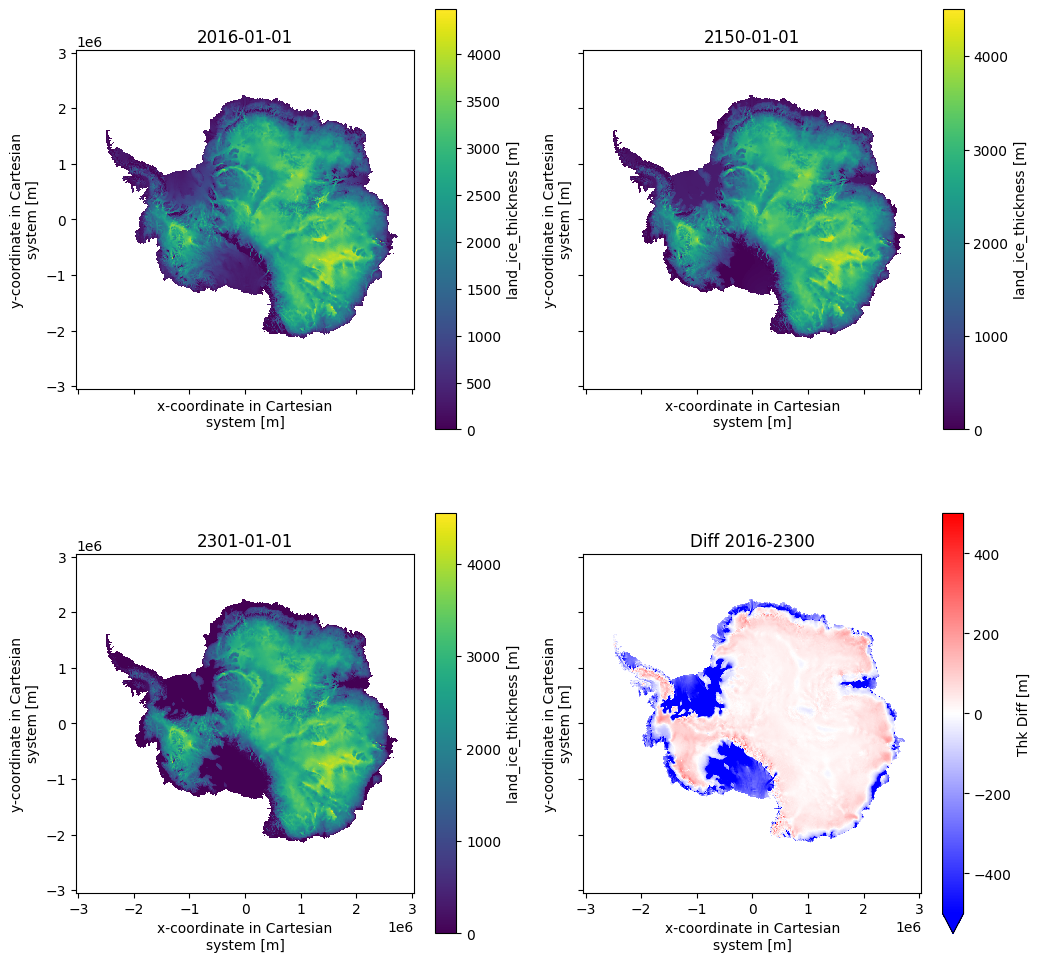

In [26]:
inds =[0, 134, -1]

f, ax = plt.subplots(2, 2, figsize = (12, 12), sharex=True, sharey=True)
ax = ax.flatten()
for i,ind in enumerate(inds):

    d_thk.lithk[ind, :, :].plot(ax = ax[i])
    ax[i].set_title(d.time.values[ind].strftime().split(' ')[0])
    ax[i].set_aspect('equal')

diff = d_thk.lithk[-1, :, :] - d_thk.lithk[0, :, :]
p = diff.plot(ax=ax[3], vmin=-500, vmax=500, cmap='bwr', cbar_kwargs={'label': "Thk Diff [m]"})
ax[3].set_title('Diff 2016-2300')
ax[3].set_aspect('equal')   


### 2e.  Is ice shelf draft negative for floating mask?

In [25]:
# d_draft =xr.open_dataset(basepath+model +'/'+exp1 +'/'+draft)

Prints warning if ice shelf draft is above sea level

Text(0.5, 0, 'Runtime - years')

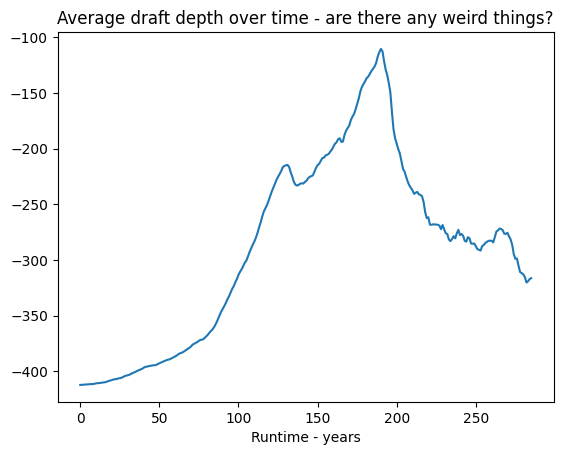

In [27]:
ts = np.zeros([d.time.size,1])

for i in range(d.time.size):
    
    m_in = d.isel(time =i).sftflf #.values
    m = m_in ==1
    shelf_draft =d_draft.base.values[i,]
    mpos = shelf_draft[m]>0
    ts[i] = np.nanmean(shelf_draft[m])
    if mpos.sum()>0:
        print('WOOPS base is above sea level at ' ,d.time[i])

plt.figure()
plt.plot(ts)
plt.title('Average draft depth over time - are there any weird things?')
plt.xlabel('Runtime - years')
#plt.plot(ts)

###  2f.  What are max and min BMB values? There should be very limited +ve values

In [40]:
d_bmb=xr.open_dataset(basepath+model +'/'+exp1 +'/'+bmboutput)
bmb = d_bmb.libmassbffl.values[0,]*365*24*60*60/917
print('Min BMB (melting):', np.nanmin(bmb), 'm/a')
print('Max BMB (refreezing):', np.nanmax(bmb), 'm/a')

/home/mkjs0/.local/lib/python3.10/site-packages/xarray/coding/times.py:995: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/mkjs0/.local/lib/python3.10/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


Min BMB (melting): -1.2990888541868602 m/a
Max BMB (refreezing): 2.060480847640632 m/a


### 2g. Plot example BMB for West Antarctica

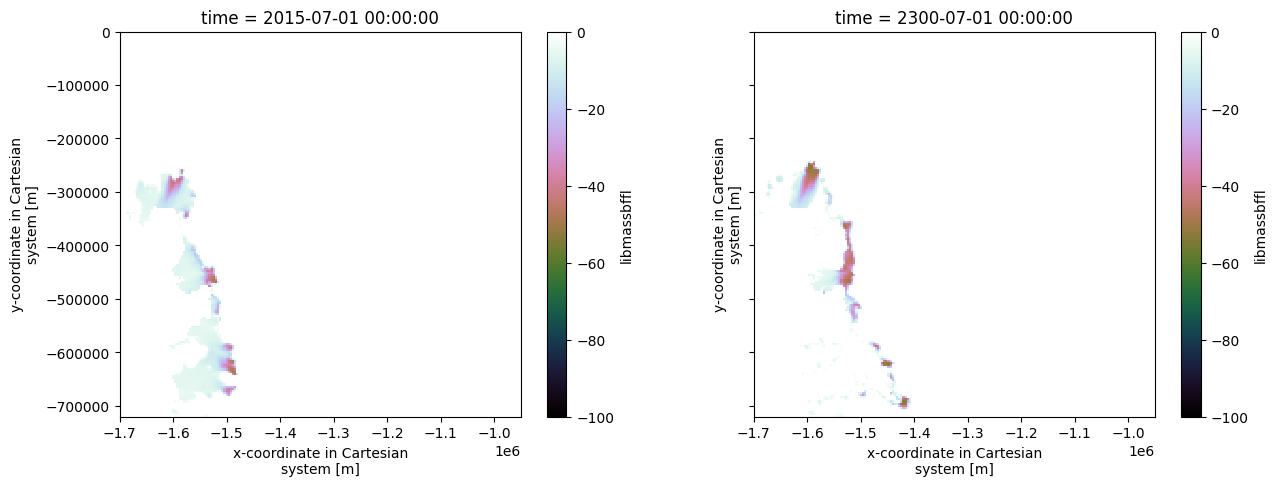

In [28]:
y_range = (-720000, 0)
x_range = (-1700000, -950000)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for i in range(2):
    bmb = d_bmb.libmassbffl[0 if i==0 else -1, :, :] * 365 * 24 * 60 * 60 / 917
    bmb.plot(ax=ax[i], cmap='cubehelix', vmin=-100, vmax=0)
    ax[i].set_xlim(x_range)
    ax[i].set_ylim(y_range)
    ax[i].set_aspect('equal')

### 2h. Check for basal melt on grounded cells ?

Prints warning if melt is found on grounded cells

In [29]:
for i in range(d.time.size):
    m_in=d.sftflf.values[i,]
    m = m_in ==0
    bmb_grounded=d_bmb.libmassbffl.values[i,]
    mpos = bmb_grounded[m]>0
    if mpos.sum()>0:
        print('WOOPS melting at fully grounded cells ' ,d.time[i])


### 2i. Plot total BMB over time

In [30]:
tendlibmassbf = 'tendlibmassbf_' + model_base + '_' + exp2 + '.nc'
tendlibmassbffl = 'tendlibmassbffl_' + model_base + '_' + exp2 + '.nc'

dbmb1 =xr.open_dataset(basepath + '/' + model + '/' + exp1 + '/' + tendlibmassbf)
dbmb2 =xr.open_dataset(basepath + '/' + model + '/' + exp1 + '/' + tendlibmassbffl)

line1, = plt.plot(dbmb1.tendlibmassbf, label='Total BMB')
line2, = plt.plot(dbmb2.tendlibmassbffl, label='Floating BMB')
plt.legend()
plt.xlabel('Runtime - years')

#diff=dbmb1.tendlibmassbf-dbmb2.tendlibmassbffl


AttributeError: 'Dataset' object has no attribute 'tendlibmassbf'